# Stock Price Forecasting: Feature Engineering Demo

**Application**: Predicting stock price movements using feature engineering transforms from EE104 lecture

**Stock**: HPG (Hoa Phat Group) - One of Vietnam's largest steel producers (VN30 index)  
**Data Range**: 2022-2026 (most recent 4 years)  
**Task**: Predict tomorrow's price movement (up/down)

## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Set plotting defaults
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Part 1: Load & Explore Data

Dataset Shape: (1000, 7)
Date Range: 2022-01-04 00:00:00 to 2026-01-07 00:00:00
Total Trading Days: 1000

First 5 rows:
        time   open   high    low  close    volume Ticker
0 2022-01-04  26.83  27.06  26.72  26.80  20100700    HPG
1 2022-01-05  26.89  27.15  26.83  26.83  18760700    HPG
2 2022-01-06  26.66  26.77  26.43  26.43  17172700    HPG
3 2022-01-07  26.43  26.49  26.17  26.26  16335300    HPG
4 2022-01-10  26.29  26.75  26.09  26.17  17477500    HPG

Last 5 rows:
          time   open   high    low  close    volume Ticker
995 2025-12-30  26.70  26.85  26.50  26.50  24581900    HPG
996 2025-12-31  26.45  26.60  26.35  26.40  20149700    HPG
997 2026-01-05  26.40  26.55  25.70  25.95  46487900    HPG
998 2026-01-06  26.00  26.20  25.35  25.95  39616600    HPG
999 2026-01-07  25.95  26.75  25.95  26.60  37249700    HPG


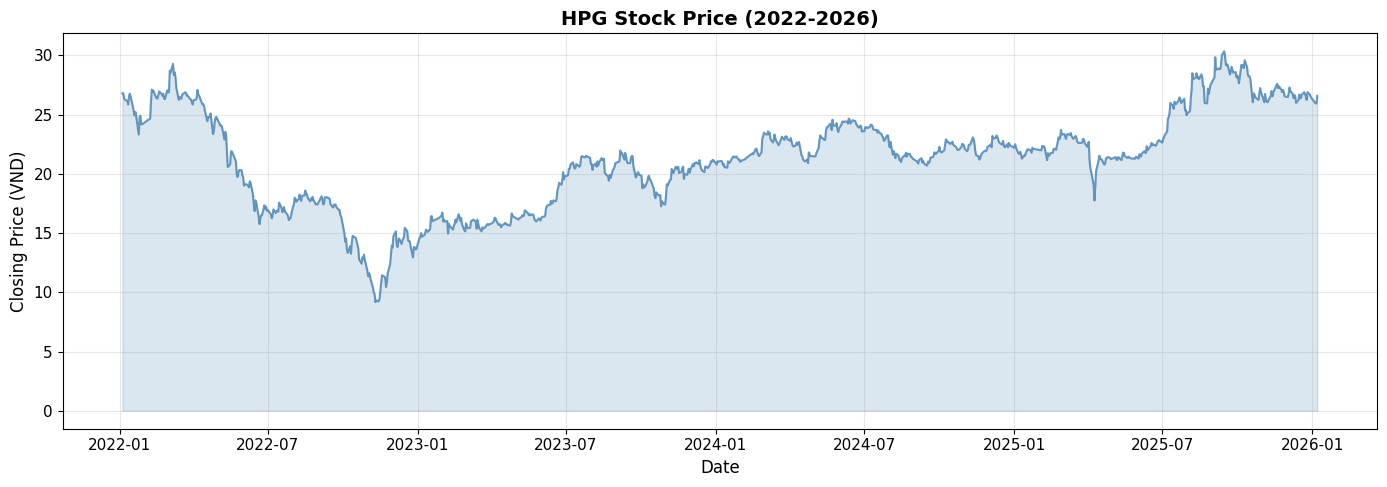


 Data loaded: HPG stock from 2022-01-04 to 2026-01-07


In [2]:
# Load VN30 dataset
df_all = pd.read_csv('data/VN30_Dataset_2015_2026.csv')

# Filter for HPG stock only
df = df_all[df_all['Ticker'] == 'HPG'].copy()

# Convert time to datetime
df['time'] = pd.to_datetime(df['time'])

# Sort by time
df = df.sort_values('time').reset_index(drop=True)

# Filter for recent data (2022-2026)
df = df[df['time'] >= '2022-01-01'].reset_index(drop=True)

# Display basic info
print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['time'].min()} to {df['time'].max()}")
print(f"Total Trading Days: {len(df)}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nLast 5 rows:")
print(df.tail())

# Plot raw closing price
plt.figure(figsize=(14, 5))
plt.plot(df['time'], df['close'], linewidth=1.5, color='steelblue', alpha=0.8)
plt.fill_between(df['time'], df['close'], alpha=0.2, color='steelblue')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (VND)', fontsize=12)
plt.title('HPG Stock Price (2022-2026)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Data loaded: HPG stock from {df['time'].min().strftime('%Y-%m-%d')} to {df['time'].max().strftime('%Y-%m-%d')}")

---
## Part 2: Extract Raw Features

Before applying transforms, we extract basic features from OHLCV (Open, High, Low, Close, Volume) data.

In [3]:
# Create a copy for feature engineering
features = df[['time', 'open', 'high', 'low', 'close', 'volume']].copy()

# 1. Daily Return (%)
features['return'] = (features['close'] - features['close'].shift(1)) / features['close'].shift(1) * 100

# 2. Price Range (High - Low)
features['price_range'] = features['high'] - features['low']

# 3. Volume Change (%)
features['volume_change'] = (features['volume'] - features['volume'].shift(1)) / features['volume'].shift(1) * 100

# 4. Moving Averages
features['ma_5'] = features['close'].rolling(window=5).mean()
features['ma_20'] = features['close'].rolling(window=20).mean()

# 5. Price relative to MA
features['price_vs_ma5'] = (features['close'] - features['ma_5']) / features['ma_5'] * 100
features['price_vs_ma20'] = (features['close'] - features['ma_20']) / features['ma_20'] * 100

# 6. Day of week (0=Monday, 6=Sunday)
features['day_of_week'] = features['time'].dt.dayofweek

# Remove NaN rows (from shifting and rolling)
features = features.dropna().reset_index(drop=True)

# Display statistics
print("Raw Features Statistics")
print("=" * 80)
print(features[['return', 'price_range', 'volume_change', 'ma_5', 'ma_20']].describe())

print(f"\n Extracted {len(features)} samples with {features.shape[1]} raw features")
print(f"   Features: return, price_range, volume_change, moving averages, day_of_week")

Raw Features Statistics
           return  price_range  volume_change        ma_5       ma_20
count  981.000000   981.000000     981.000000  981.000000  981.000000
mean     0.032122     0.525637      16.247736   21.110671   21.101009
std      2.119065     0.287863     102.061892    4.090282    4.027898
min     -7.001321     0.000000     -96.027949    9.410000   10.632500
25%     -0.961538     0.330000     -28.579190   17.910000   17.933000
50%      0.000000     0.460000      -1.255169   21.444000   21.467500
75%      1.046278     0.650000      35.141859   23.348000   23.209500
max      6.910039     2.200000    2388.017708   29.730000   29.040000

 Extracted 981 samples with 14 raw features
   Features: return, price_range, volume_change, moving averages, day_of_week


---
## Part 3: Feature Engineering Transforms

Now we apply the 6 transforms from the EE104 lecture to create engineered features.

### Transform 1: Standardization (Z-Scoring)

**Purpose**: Normalize features to mean=0, std=1 for comparability across different scales.

**Formula**: $z = \frac{x - \mu}{\sigma}$

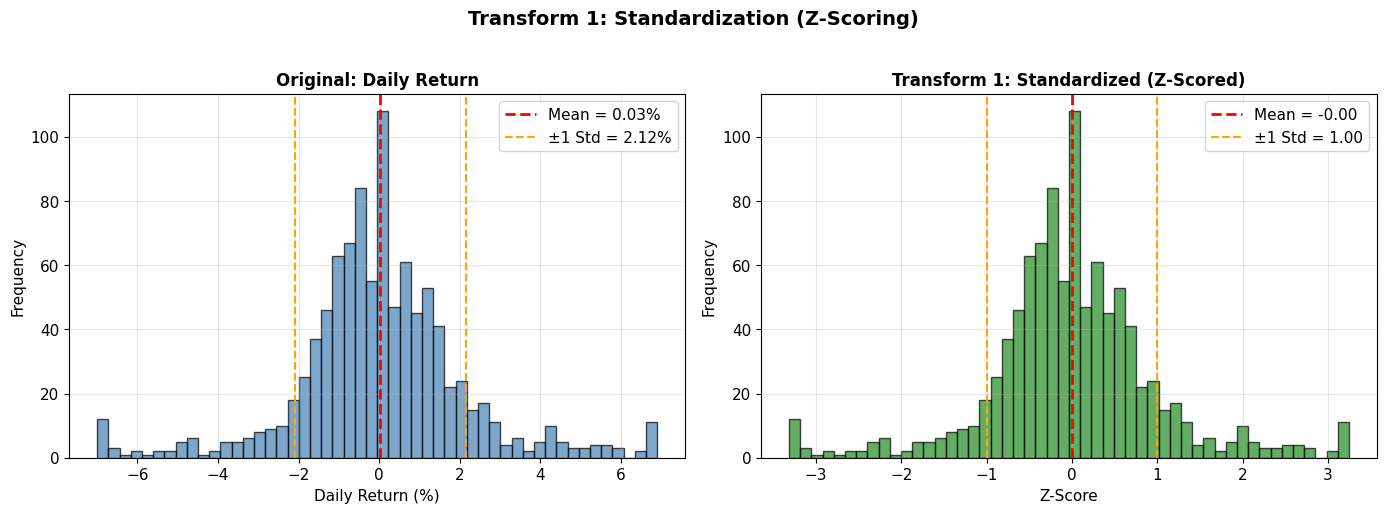

 Transform 1 Complete: Z-scored features have mean≈0, std≈1
   Original Return: mean=0.03%, std=2.12%
   Z-scored Return: mean=-0.00, std=1.00


In [4]:
# Apply z-scoring to return and volume_change
features['return_zscore'] = (features['return'] - features['return'].mean()) / features['return'].std()
features['volume_change_zscore'] = (features['volume_change'] - features['volume_change'].mean()) / features['volume_change'].std()

# Visualize: Before and After
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original Return
axes[0].hist(features['return'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(features['return'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {features["return"].mean():.2f}%')
axes[0].axvline(features['return'].mean() + features['return'].std(), color='orange', linestyle='--', 
                linewidth=1.5, label=f'±1 Std = {features["return"].std():.2f}%')
axes[0].axvline(features['return'].mean() - features['return'].std(), color='orange', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Daily Return (%)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Original: Daily Return', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Z-scored Return
axes[1].hist(features['return_zscore'], bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
axes[1].axvline(features['return_zscore'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {features["return_zscore"].mean():.2f}')
axes[1].axvline(features['return_zscore'].mean() + features['return_zscore'].std(), color='orange', 
                linestyle='--', linewidth=1.5, label=f'±1 Std = {features["return_zscore"].std():.2f}')
axes[1].axvline(features['return_zscore'].mean() - features['return_zscore'].std(), color='orange', 
                linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Z-Score', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Transform 1: Standardized (Z-Scored)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Transform 1: Standardization (Z-Scoring)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f" Transform 1 Complete: Z-scored features have mean≈0, std≈1")
print(f"   Original Return: mean={features['return'].mean():.2f}%, std={features['return'].std():.2f}%")
print(f"   Z-scored Return: mean={features['return_zscore'].mean():.2f}, std={features['return_zscore'].std():.2f}")

---
### Transform 2: Gamma/Log Transform (γ = 0.5)

**Purpose**: Compress wide-range features to reduce impact of extreme values and improve normality.

**Formula**: $y = x^\gamma$

**Effect**: γ=0.5 (square root) compresses large values more than small ones, stabilizing variance.

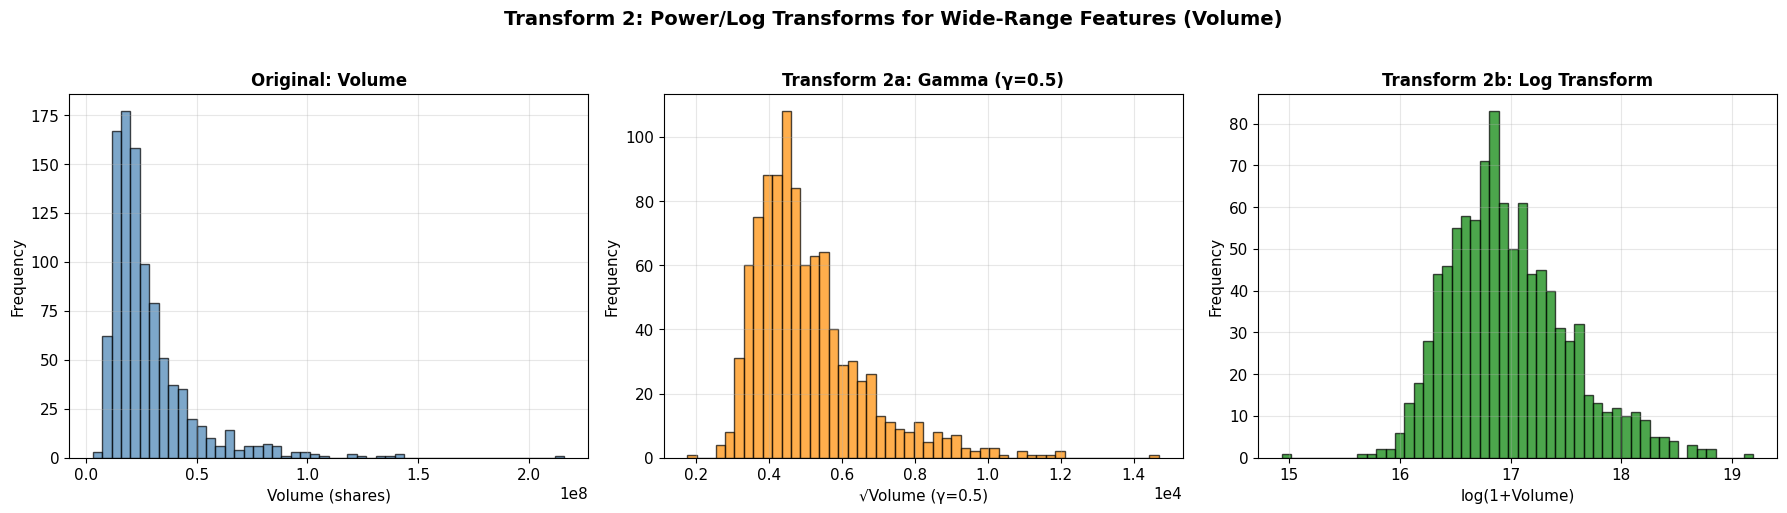

✓ Transform 2 Complete: Applied gamma/log to VOLUME (wide dynamic range)
   Original volume range: [3066909, 215999100]
   Gamma (γ=0.5):     [1751, 14697]
   Log transform:        [14.94, 19.19]

   Why volume? It varies by orders of magnitude (millions to billions)
   Why NOT returns? They're already normalized percentages (-10% to +10%)


In [5]:
# Apply gamma transform to volume (NOT returns - they're already normalized!)
# Volume has wide dynamic range (millions to billions) - perfect candidate for gamma/sqrt transform
gamma = 0.5
features['volume_gamma'] = features['volume'] ** gamma  # Square root transform

# Also create log transform (alternative approach for comparison)
features['volume_log'] = np.log1p(features['volume'])  # log(1+x) to handle zeros safely

# Visualize: Before and After
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original Volume Distribution
axes[0].hist(features['volume'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Volume (shares)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Original: Volume', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# Plot 2: Gamma (Square Root) Transformed
axes[1].hist(features['volume_gamma'], bins=50, color='darkorange', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('√Volume (γ=0.5)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Transform 2a: Gamma (γ=0.5)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# Plot 3: Log Transformed
axes[2].hist(features['volume_log'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('log(1+Volume)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Transform 2b: Log Transform', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle('Transform 2: Power/Log Transforms for Wide-Range Features (Volume)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"✓ Transform 2 Complete: Applied gamma/log to VOLUME (wide dynamic range)")
print(f"   Original volume range: [{features['volume'].min():.0f}, {features['volume'].max():.0f}]")
print(f"   Gamma (γ={gamma}):     [{features['volume_gamma'].min():.0f}, {features['volume_gamma'].max():.0f}]")
print(f"   Log transform:        [{features['volume_log'].min():.2f}, {features['volume_log'].max():.2f}]")
print(f"\n   Why volume? It varies by orders of magnitude (millions to billions)")
print(f"   Why NOT returns? They're already normalized percentages (-10% to +10%)")

---
### Transform 3: Positive/Negative Split

**Purpose**: Allow models to learn different behaviors for gains vs losses (asymmetric market behavior).

**Formula**:
- Positive part: $x^+ = \max(x, 0)$
- Negative part: $x^- = \min(x, 0)$

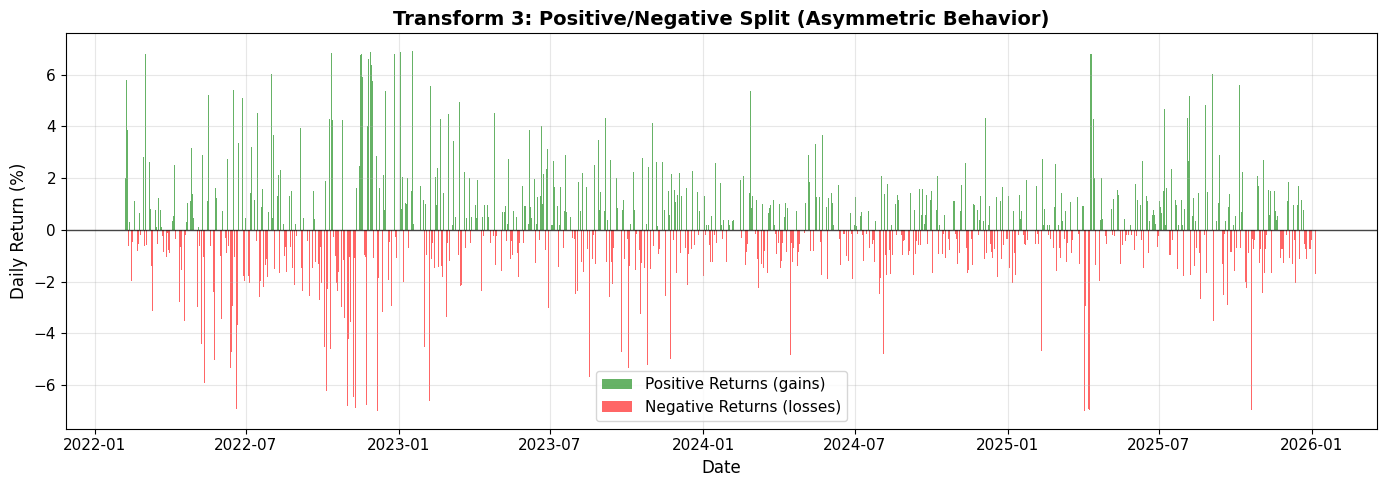

 Transform 3 Complete: Split into positive/negative components
   Up days: 441 (avg return: +1.67%)
   Down days: 475 (avg return: -1.48%)
   → Models can learn asymmetric responses to gains vs losses


In [6]:
# Split return into positive and negative parts
features['return_positive'] = np.maximum(features['return'], 0)
features['return_negative'] = np.minimum(features['return'], 0)

# Visualize: Time series with color coding
plt.figure(figsize=(14, 5))

# Plot positive returns in green
positive_mask = features['return'] > 0
plt.bar(features.loc[positive_mask, 'time'], features.loc[positive_mask, 'return'], 
        color='green', alpha=0.6, label='Positive Returns (gains)', width=1)

# Plot negative returns in red
negative_mask = features['return'] < 0
plt.bar(features.loc[negative_mask, 'time'], features.loc[negative_mask, 'return'], 
        color='red', alpha=0.6, label='Negative Returns (losses)', width=1)

plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.7)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Return (%)', fontsize=12)
plt.title('Transform 3: Positive/Negative Split (Asymmetric Behavior)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Statistics
up_days = (features['return'] > 0).sum()
down_days = (features['return'] < 0).sum()
up_avg = features.loc[features['return'] > 0, 'return'].mean()
down_avg = features.loc[features['return'] < 0, 'return'].mean()

print(f" Transform 3 Complete: Split into positive/negative components")
print(f"   Up days: {up_days} (avg return: +{up_avg:.2f}%)")
print(f"   Down days: {down_days} (avg return: {down_avg:.2f}%)")
print(f"   → Models can learn asymmetric responses to gains vs losses")

---
### Transform 4: Binning/Quantizing

**Purpose**: Discretize continuous features into categorical bins to capture non-linear threshold effects.

**Method**: Divide volume into 5 equal-frequency bins (quintiles), then one-hot encode.

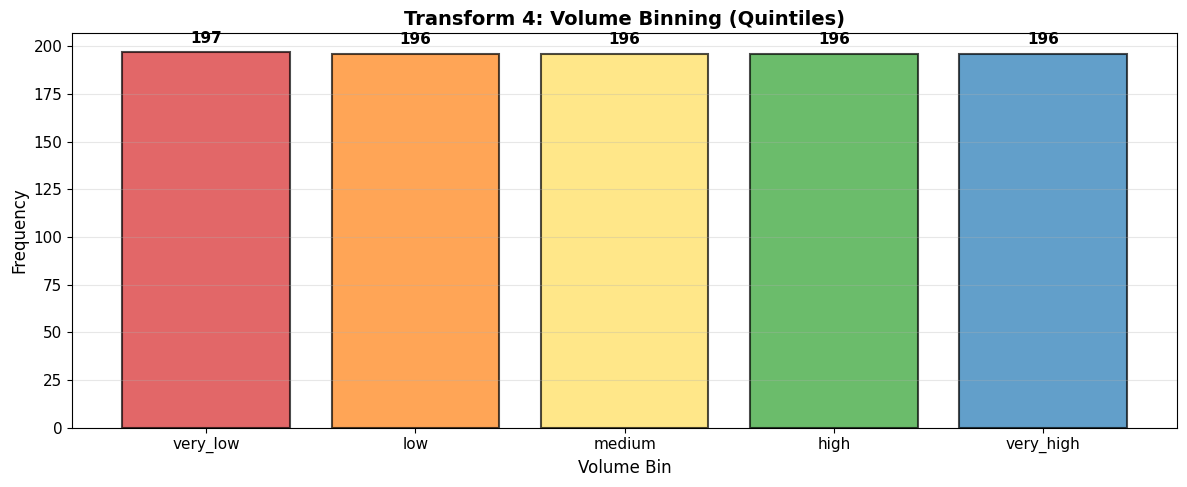

One-Hot Encoded Volume Bins (first 10 rows):
     volume volume_bin  volume_very_low  volume_low  volume_medium  \
0  16609600        low            False        True          False   
1  26528800       high            False       False          False   
2  40297200  very_high            False       False          False   
3  23598200     medium            False       False           True   
4  17343300        low            False        True          False   
5  18246700        low            False        True          False   
6  15564400        low            False        True          False   
7   9350300   very_low             True       False          False   
8  11353300   very_low             True       False          False   
9  21375700     medium            False       False           True   

   volume_high  volume_very_high  
0        False             False  
1         True             False  
2        False              True  
3        False             False  
4        

In [7]:
# Create 5 volume bins using quintiles
features['volume_bin'] = pd.qcut(features['volume'], q=5, labels=['very_low', 'low', 'medium', 'high', 'very_high'])

# One-hot encode the bins
volume_dummies = pd.get_dummies(features['volume_bin'], prefix='volume')
features = pd.concat([features, volume_dummies], axis=1)

# Visualize bin distribution
bin_counts = features['volume_bin'].value_counts().sort_index()

plt.figure(figsize=(12, 5))

# Bar plot
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']
plt.bar(bin_counts.index, bin_counts.values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

plt.xlabel('Volume Bin', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Transform 4: Volume Binning (Quintiles)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)

# Annotate with counts
for i, (bin_name, count) in enumerate(bin_counts.items()):
    plt.text(i, count + 5, str(count), ha='center', fontsize=11, fontweight='bold')

plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Show one-hot encoding
print("One-Hot Encoded Volume Bins (first 10 rows):")
print(features[['volume', 'volume_bin', 'volume_very_low', 'volume_low', 'volume_medium', 'volume_high', 'volume_very_high']].head(10))

print(f"\n Transform 4 Complete: Volume discretized into 5 bins, one-hot encoded")
print(f"   Created 5 binary features: volume_very_low, volume_low, volume_medium, volume_high, volume_very_high")

---
### Transform 5: Interaction Features (Expert-Level)

**Purpose**: Capture joint effects of features


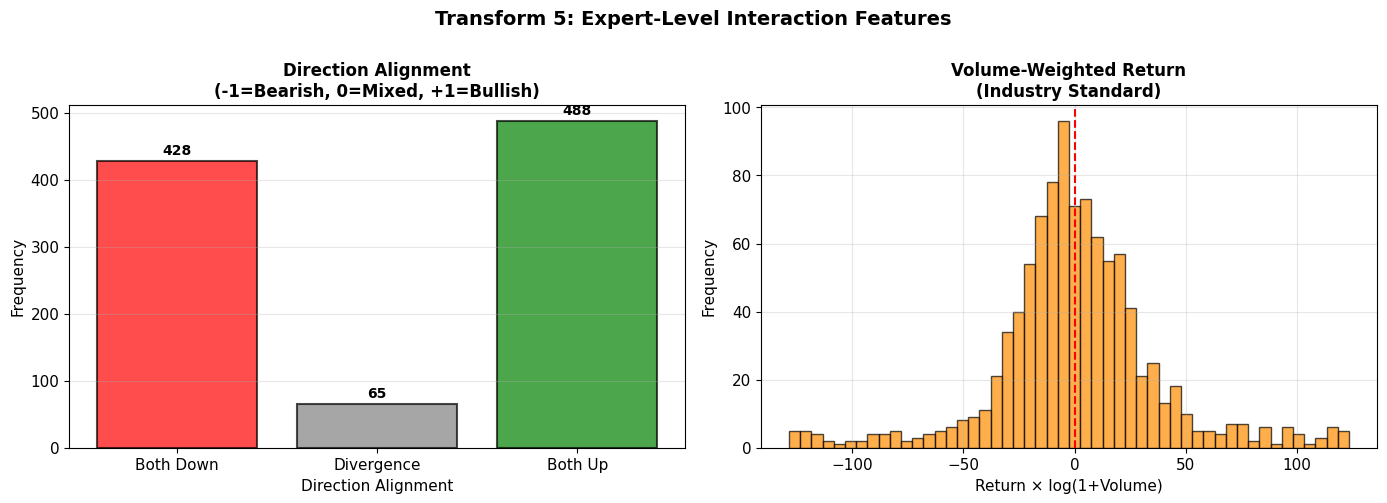

✓ Transform 5 Complete: 2 interaction features
  Direction Alignment: Bullish=488, Mixed=65, Bearish=428
  Volume-Weighted Return range: [-128.49, 123.52]


In [16]:
# Create target for visualization
features['next_day_return'] = features['return'].shift(-1)
features['next_day_up'] = (features['next_day_return'] > 0).astype(int)

# INTERACTION 1: Direction Alignment (sign-based)
# +1 = both up, -1 = both down, 0 = divergence
features['direction_alignment'] = np.sign(features['return']) * np.sign(features['volume_change'])

# INTERACTION 2: Volume-Weighted Return (industry standard)
features['volume_weighted_return'] = features['return'] * np.log1p(features['volume'])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Direction Alignment
alignment_counts = features['direction_alignment'].value_counts().sort_index()
colors_align = {-1.0: 'red', 0.0: 'gray', 1.0: 'green'}
axes[0].bar(alignment_counts.index, alignment_counts.values, 
            color=[colors_align.get(x, 'blue') for x in alignment_counts.index],
            alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Direction Alignment', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Direction Alignment\n(-1=Bearish, 0=Mixed, +1=Bullish)', fontsize=12, fontweight='bold')
axes[0].set_xticks([-1, 0, 1])
axes[0].set_xticklabels(['Both Down', 'Divergence', 'Both Up'])
axes[0].grid(alpha=0.3, axis='y')
for val, count in alignment_counts.items():
    axes[0].text(val, count + 10, str(count), ha='center', fontsize=10, fontweight='bold')

# Plot 2: Volume-Weighted Return
axes[1].hist(features['volume_weighted_return'], bins=50, color='darkorange', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Return × log(1+Volume)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Volume-Weighted Return\n(Industry Standard)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Transform 5: Expert-Level Interaction Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Transform 5 Complete: 2 interaction features")
print(f"  Direction Alignment: Bullish={((features['direction_alignment']==1).sum())}, Mixed={((features['direction_alignment']==0).sum())}, Bearish={((features['direction_alignment']==-1).sum())}")
print(f"  Volume-Weighted Return range: [{features['volume_weighted_return'].min():.2f}, {features['volume_weighted_return'].max():.2f}]")

---
### Transform 6: Cyclic Time Features (Day-of-Week Encoding)

**Purpose**: Represent cyclic features (days, months) without imposing false ordering.

**Formula**:
- $\text{day\_sin} = \sin(2\pi \cdot \frac{\text{day}}{7})$
- $\text{day\_cos} = \cos(2\pi \cdot \frac{\text{day}}{7})$

**Why?** Monday (0) and Friday (4) are not "far apart" numerically, but they are far in the week cycle. Circular encoding preserves this.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


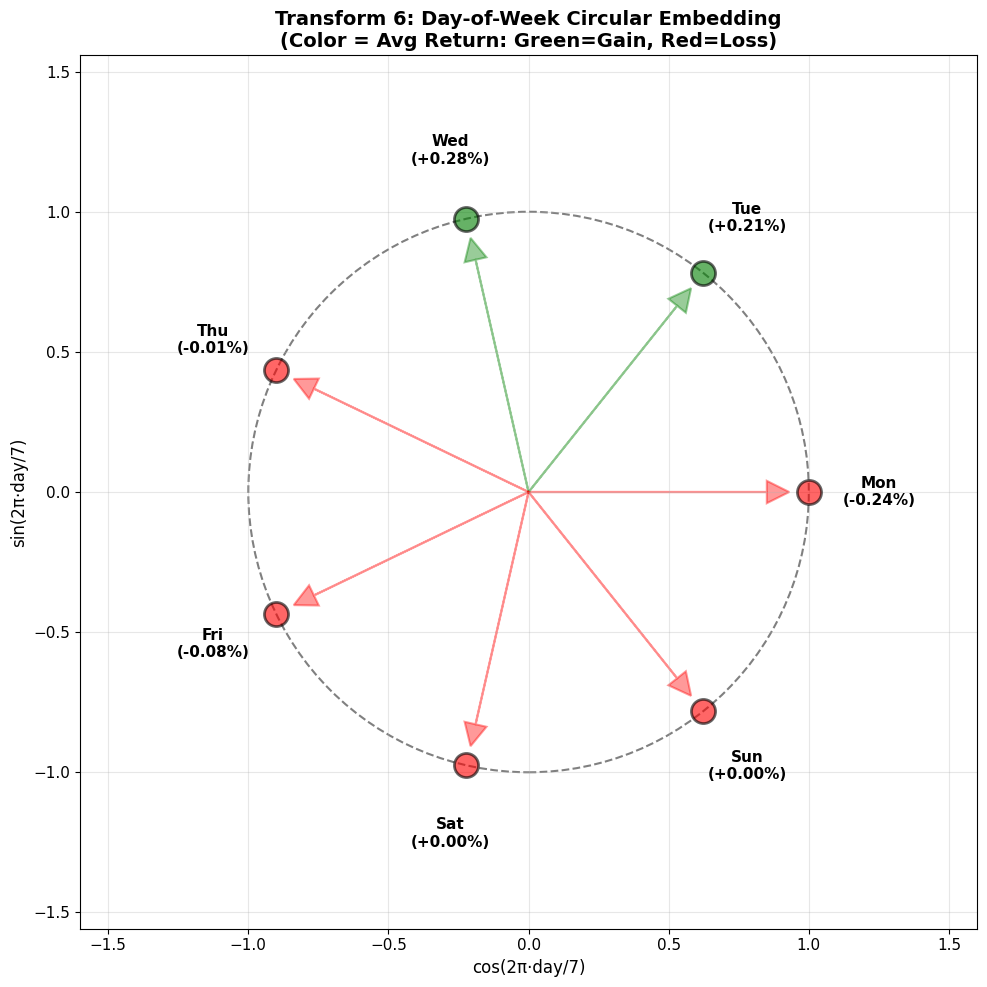

 Transform 6 Complete: Cyclic encoding for day of week

Average Return by Day of Week:
  Mon: -0.24%
  Tue: +0.21%
  Wed: +0.28%
  Thu: -0.01%
  Fri: -0.08%


In [9]:
# Create circular encoding for day of week
features['day_sin'] = np.sin(2 * np.pi * features['day_of_week'] / 7)
features['day_cos'] = np.cos(2 * np.pi * features['day_of_week'] / 7)

# Visualize circular encoding
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
days = np.arange(0, 7)
day_sin = np.sin(2 * np.pi * days / 7)
day_cos = np.cos(2 * np.pi * days / 7)

# Calculate average return for each day of week
day_avg_returns = features.groupby('day_of_week')['return'].mean()

plt.figure(figsize=(10, 10))

# Draw unit circle
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=1.5)
plt.gca().add_patch(circle)

# Plot day points with color based on average return
for i in range(7):
    avg_ret = day_avg_returns[i] if i in day_avg_returns.index else 0
    color = 'green' if avg_ret > 0 else 'red'
    
    # Plot point
    plt.scatter(day_cos[i], day_sin[i], s=300, c=color, alpha=0.6, edgecolors='black', linewidth=2, zorder=3)
    
    # Add label
    offset_x = day_cos[i] * 1.25
    offset_y = day_sin[i] * 1.25
    plt.annotate(f"{day_names[i]}\n({avg_ret:+.2f}%)", 
                (day_cos[i], day_sin[i]), 
                xytext=(offset_x, offset_y),
                fontsize=11, fontweight='bold', ha='center', va='center')
    
    # Add arrow from origin
    plt.arrow(0, 0, day_cos[i] * 0.85, day_sin[i] * 0.85, 
             head_width=0.08, head_length=0.08, 
             fc=color, ec=color, alpha=0.4, linewidth=1.5)

plt.xlabel('cos(2π·day/7)', fontsize=12)
plt.ylabel('sin(2π·day/7)', fontsize=12)
plt.title('Transform 6: Day-of-Week Circular Embedding\n(Color = Avg Return: Green=Gain, Red=Loss)', 
          fontsize=14, fontweight='bold')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.xlim(-1.6, 1.6)
plt.ylim(-1.6, 1.6)
plt.tight_layout()
plt.show()

print(" Transform 6 Complete: Cyclic encoding for day of week")
print("\nAverage Return by Day of Week:")
for day_num, day_name in enumerate(day_names):
    if day_num in day_avg_returns.index:
        print(f"  {day_name}: {day_avg_returns[day_num]:+.2f}%")

---
## Part 4: Final Feature Matrix

Now we have successfully engineered features using all 6 transforms from the EE104 lecture. Let's examine the final feature set.

In [ ]:
# Select engineered features for final matrix
engineered_features = [
    # Raw features
    'return', 'price_range', 'volume_change', 'ma_5', 'ma_20', 
    'price_vs_ma5', 'price_vs_ma20',
    
    # Transform 1: Standardization
    'return_zscore', 'volume_change_zscore',
    
    # Transform 2: Gamma/Log (applied to volume - wide range feature)
    'volume_gamma', 'volume_log',
    
    # Transform 3: Pos/Neg Split
    'return_positive', 'return_negative',
    
    # Transform 4: Binning (one-hot encoded)
    'volume_very_low', 'volume_low', 'volume_medium', 'volume_high', 'volume_very_high',
    
    # Transform 5: Interactions
    'direction_alignment', 'volume_weighted_return',
    
    # Transform 6: Cyclic encoding
    'day_sin', 'day_cos'
]

# Create final feature matrix
X = features[engineered_features].copy()

print("=" * 80)
print("FINAL ENGINEERED FEATURE MATRIX")
print("=" * 80)
print(f"Shape: {X.shape[0]} samples × {X.shape[1]} features\n")
print("Features by Transform:")
print("  Raw (7): return, price_range, volume_change, MAs")
print("  T1 - Standardization (2): return_zscore, volume_change_zscore")
print("  T2 - Gamma/Log (2): volume_gamma, volume_log")
print("  T3 - Pos/Neg Split (2): return_positive, return_negative")
print("  T4 - Binning (5): volume quintiles")
print("  T5 - Interactions (2): direction_alignment, volume_weighted_return")
print("  T6 - Cyclic (2): day_sin, day_cos")
print(f"  TOTAL: {X.shape[1]} features")
print("=" * 80)
print("\nFeature Statistics:")
print(X.describe())
print("\n✓ All transforms follow industry best practices")
print("=" * 80)

FINAL ENGINEERED FEATURE MATRIX

Shape: 981 samples × 23 features

Features by Transform:
--------------------------------------------------------------------------------
  Raw Features (7):                    return, price_range, volume_change, MAs, etc.
  Transform 1 - Standardization (2):   return_zscore, volume_change_zscore
  Transform 2 - Gamma/Log (2):         volume_gamma, volume_log
  Transform 3 - Pos/Neg Split (2):     return_positive, return_negative
  Transform 4 - Binning (5):           volume_very_low ... volume_very_high
  Transform 5 - Interactions (3):      zscore_product, direction_align, vol_weighted
  Transform 6 - Cyclic Encoding (2):   day_sin, day_cos
--------------------------------------------------------------------------------
  TOTAL: 23 features

First 10 rows of engineered features:
     return  price_range  volume_change    ma_5    ma_20  price_vs_ma5  \
0  2.025630         1.09      11.163463  24.550  25.5030      0.529532   
1  5.794165         1.46   